In [72]:
import pandas as pd
import numpy as np

In [73]:
df = pd.read_csv("../data/cleaned_loans.csv")

In [74]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,revol_util,revol_bal,open_acc,total_acc,pub_rec,earliest_cr_line,issue_d,addr_state,loan_status,fico
0,3600.0,36.0,13.99,123.03,C,C4,-1.0,MORTGAGE,55000.0,Not Verified,...,29.7,2765.0,7.0,13.0,0.0,2003-08-01,2015-12-01,PA,Fully Paid,677.0
1,24700.0,36.0,11.99,820.28,C,C1,-1.0,MORTGAGE,65000.0,Not Verified,...,19.2,21470.0,22.0,38.0,0.0,1999-12-01,2015-12-01,SD,Fully Paid,717.0
2,20000.0,60.0,10.78,432.66,B,B4,-1.0,MORTGAGE,63000.0,Not Verified,...,56.2,7869.0,6.0,18.0,0.0,2000-08-01,2015-12-01,IL,Fully Paid,697.0
3,10400.0,60.0,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,64.5,21929.0,12.0,35.0,0.0,1998-06-01,2015-12-01,PA,Fully Paid,697.0
4,11950.0,36.0,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,68.4,8822.0,5.0,6.0,0.0,1987-10-01,2015-12-01,GA,Fully Paid,692.0


In [75]:
df.shape

(1345350, 23)

## Loan-to-Income Ratio

In [76]:
df["loan_income_ratio"] = (
    df["loan_amnt"] /
    df["annual_inc"]
).round(4)

df[[
    "loan_amnt",
    "annual_inc",
    "loan_income_ratio"
]].head()

,loan_amnt,annual_inc,loan_income_ratio
0,3600.0,55000.0,0.0655
1,24700.0,65000.0,0.3800
2,20000.0,63000.0,0.3175
3,10400.0,104433.0,0.0996
4,11950.0,34000.0,0.3515


Higher ratios indicate larger borrowing relative to income and generally imply higher repayment risk.

## DTI Bucket

In [77]:
bins = [-1,10,20,30,40,100]

labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

df["dti_bucket"] = pd.cut(
    df["dti"],
    bins=bins,
    labels=labels
)

df["dti_bucket"].value_counts()

dti_bucket
Low          562502
Moderate     408353
Very Low     246186
High         121541
Very High      6233
Name: count, dtype: int64

High DTI indicates that a borrower already carries significant debt.

## Income Bucket

In [78]:
income_bins = [
    0,
    40000,
    80000,
    120000,
    200000,
    np.inf
]

income_labels = [
    "Low",
    "Lower Middle",
    "Middle",
    "Upper Middle",
    "High"
]

df["income_bucket"] = pd.cut(
    df["annual_inc"],
    bins=income_bins,
    labels=income_labels
)

df["income_bucket"].value_counts()

income_bucket
Lower Middle    662983
Middle          287692
Low             245589
Upper Middle    120778
High             27947
Name: count, dtype: int64

Makes income easier to analyze and visualize.

## FICO Bucket

In [79]:
fico_bins = [
    300,
    580,
    670,
    740,
    800,
    850
]

fico_labels = [
    "Poor",
    "Fair",
    "Good",
    "Very Good",
    "Excellent"
]

df["fico_bucket"] = pd.cut(
    df["fico"],
    bins=fico_bins,
    labels=fico_labels
)

Banks rarely use raw FICO values in dashboards—they work with credit score bands.

## Revolving Utilization Bucket

In [80]:
util_bins = [
    0,
    30,
    50,
    75,
    100
]

util_labels = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

df["revol_util_bucket"] = pd.cut(
    df["revol_util"],
    bins=util_bins,
    labels=util_labels
)

High utilization often signals financial stress.

## Loan Amount Bucket

In [81]:
loan_bins = [
    0,
    5000,
    10000,
    20000,
    40000,
    np.inf
]

loan_labels = [
    "Small",
    "Medium",
    "Large",
    "Very Large",
    "Premium"
]

df["loan_amount_bucket"] = pd.cut(
    df["loan_amnt"],
    bins=loan_bins,
    labels=loan_labels
)

Useful for portfolio concentration analysis.

## Employment Category

In [82]:
conditions = [

    df["emp_length"] == -1,

    df["emp_length"] <= 1,

    df["emp_length"].between(2,5),

    df["emp_length"] > 5

]

choices = [

    "Unknown",

    "New",

    "Mid Career",

    "Experienced"

]

df["employment_category"] = np.select(

    conditions,

    choices,

    default="Experienced"

)

Employment stability often reflects repayment stability.

## Loan Term Category

In [83]:
df["term_category"] = df["term"].map({

36: "Short Term",

60: "Long Term"

})

Long-term loans usually carry greater uncertainty and may exhibit higher default rates.

## Credit History Length

In [84]:
df["earliest_cr_line"] = pd.to_datetime(
    df["earliest_cr_line"],
    errors="coerce"
)

df["issue_d"] = pd.to_datetime(
    df["issue_d"],
    errors="coerce"
)

In [85]:
df["credit_history_years"] = (

df["issue_d"]

-

df["earliest_cr_line"]

).dt.days / 365

In [86]:
df["credit_history_years"] = df[
    "credit_history_years"
].round(1)

In [87]:
df[
    [
        "earliest_cr_line",
        "issue_d",
        "credit_history_years"
    ]
].head()

,earliest_cr_line,issue_d,credit_history_years
0,2003-08-01,2015-12-01,12.3
1,1999-12-01,2015-12-01,16.0
2,2000-08-01,2015-12-01,15.3
3,1998-06-01,2015-12-01,17.5
4,1987-10-01,2015-12-01,28.2


Longer credit history generally improves confidence in assessing borrower behavior.

## Rule-Based Risk Segment

In [88]:
conditions = [

    (df["fico"] >= 740) &
    (df["dti"] < 20),

    (df["fico"] >= 670) &
    (df["dti"] < 30),

    (df["fico"] >= 580) &
    (df["dti"] < 40)

]

choices = [

    "Low Risk",

    "Medium Risk",

    "High Risk"

]

df["risk_segment"] = np.select(

    conditions,

    choices,

    default="Very High Risk"

)

This provides a simple benchmark against which we'll later compare the machine learning model.

## Check Engineered Features

In [89]:
engineered = [

"loan_income_ratio",

"dti_bucket",

"income_bucket",

"fico_bucket",

"revol_util_bucket",

"loan_amount_bucket",

"employment_category",

"term_category",

"credit_history_years",

"risk_segment"

]

df[engineered].head()

,loan_income_ratio,dti_bucket,income_bucket,fico_bucket,revol_util_bucket,loan_amount_bucket,employment_category,term_category,credit_history_years,risk_segment
0,0.0655,Very Low,Lower Middle,Good,Low,Small,Unknown,Short Term,12.3,Medium Risk
1,0.3800,Low,Lower Middle,Good,Low,Very Large,Unknown,Short Term,16.0,Medium Risk
2,0.3175,Low,Lower Middle,Good,High,Large,Unknown,Long Term,15.3,Medium Risk
3,0.0996,Moderate,Middle,Good,High,Large,Mid Career,Long Term,17.5,Medium Risk
4,0.3515,Low,Low,Good,High,Large,Mid Career,Short Term,28.2,Medium Risk


## Check Missing Values

In [90]:
df[engineered].isnull().sum()

loan_income_ratio           0
dti_bucket                535
income_bucket             361
fico_bucket                 0
revol_util_bucket       11663
loan_amount_bucket          0
employment_category         0
term_category               0
credit_history_years        0
risk_segment                0
dtype: int64

In [91]:
df["dti_bucket"] = (
    df["dti_bucket"]
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)

df["income_bucket"] = (
    df["income_bucket"]
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)

df["revol_util_bucket"] = (
    df["revol_util_bucket"]
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)

In [92]:
df[engineered].isnull().sum()

loan_income_ratio       0
dti_bucket              0
income_bucket           0
fico_bucket             0
revol_util_bucket       0
loan_amount_bucket      0
employment_category     0
term_category           0
credit_history_years    0
risk_segment            0
dtype: int64

In [93]:
df["is_default"] = np.where(
    df["loan_status"] == "Fully Paid",
    0,
    1
)

In [94]:
df["is_default"].value_counts()

is_default
0    1076751
1     268599
Name: count, dtype: int64

## Final model data Save

In [95]:
df.to_csv(
    "../data/final_model_data.csv",
    index=False
)

print("Final modeling dataset saved successfully!")

Final modeling dataset saved successfully!


# Models

In [96]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib

In [97]:
df = pd.read_csv("../data/final_model_data.csv")

In [98]:
if "is_default" not in df.columns:

    df["is_default"] = np.where(
        df["loan_status"]=="Fully Paid",
        0,
        1
    )

In [99]:
df.shape

(1345350, 34)

In [100]:
df.isnull().sum().sort_values(ascending=False).head(20)

loan_amnt               0
income_bucket           0
issue_d                 0
addr_state              0
loan_status             0
fico                    0
loan_income_ratio       0
dti_bucket              0
fico_bucket             0
term                    0
revol_util_bucket       0
loan_amount_bucket      0
employment_category     0
term_category           0
credit_history_years    0
risk_segment            0
earliest_cr_line        0
pub_rec                 0
total_acc               0
open_acc                0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
numeric_cols = df.select_dtypes(include=np.number).columns

np.isinf(df[numeric_cols]).sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
emp_length                0
annual_inc                0
dti                       0
delinq_2yrs               0
revol_util                0
revol_bal                 0
open_acc                  0
total_acc                 0
pub_rec                   0
fico                      0
loan_income_ratio       361
credit_history_years      0
is_default                0
dtype: int64

In [103]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti_bucket,income_bucket,fico_bucket,revol_util_bucket,loan_amount_bucket,employment_category,term_category,credit_history_years,risk_segment,is_default
0,3600.0,36.0,13.99,123.03,C,C4,-1.0,MORTGAGE,55000.0,Not Verified,...,Very Low,Lower Middle,Good,Low,Small,Unknown,Short Term,12.3,Medium Risk,0
1,24700.0,36.0,11.99,820.28,C,C1,-1.0,MORTGAGE,65000.0,Not Verified,...,Low,Lower Middle,Good,Low,Very Large,Unknown,Short Term,16.0,Medium Risk,0
2,20000.0,60.0,10.78,432.66,B,B4,-1.0,MORTGAGE,63000.0,Not Verified,...,Low,Lower Middle,Good,High,Large,Unknown,Long Term,15.3,Medium Risk,0
3,10400.0,60.0,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,Moderate,Middle,Good,High,Large,Mid Career,Long Term,17.5,Medium Risk,0
4,11950.0,36.0,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,Low,Low,Good,High,Large,Mid Career,Short Term,28.2,Medium Risk,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345345,18000.0,60.0,9.49,377.95,B,B2,5.0,OWN,130000.0,Not Verified,...,Moderate,Upper Middle,Good,Moderate,Large,Mid Career,Long Term,12.3,Medium Risk,0
1345346,29400.0,60.0,13.99,683.94,C,C3,9.0,MORTGAGE,180792.0,Not Verified,...,Moderate,Upper Middle,Good,Critical,Very Large,Experienced,Long Term,14.6,Medium Risk,0
1345347,32000.0,60.0,14.49,752.74,C,C4,3.0,MORTGAGE,157000.0,Source Verified,...,Low,Upper Middle,Good,Low,Very Large,Mid Career,Long Term,5.3,Medium Risk,1
1345348,16000.0,60.0,12.79,362.34,C,C1,-1.0,RENT,150000.0,Not Verified,...,Low,Upper Middle,Fair,High,Large,Unknown,Long Term,19.2,High Risk,0


In [104]:
df["is_default"].value_counts()

is_default
0    1076751
1     268599
Name: count, dtype: int64

In [105]:
df["is_default"].value_counts(normalize=True)*100

is_default
0    80.035009
1    19.964991
Name: proportion, dtype: float64

In [106]:
df_model = df

print(df_model.shape)

(1345350, 34)


In [107]:
print(df["is_default"].value_counts(normalize=True))

print()

print(df_model["is_default"].value_counts(normalize=True))

is_default
0    0.80035
1    0.19965
Name: proportion, dtype: float64

is_default
0    0.80035
1    0.19965
Name: proportion, dtype: float64


In [108]:
features = [

    "loan_amnt",

    "term",

    "emp_length",

    "home_ownership",

    "annual_inc",

    "purpose",

    "dti",

    "delinq_2yrs",

    "revol_util",

    "revol_bal",

    "open_acc",

    "total_acc",

    "pub_rec",

    "fico",

    "loan_income_ratio",

    "dti_bucket",

    "income_bucket",

    "fico_bucket",

    "revol_util_bucket",

    "loan_amount_bucket",

    "employment_category",

    "term_category",

    "credit_history_years"

]

In [109]:
X = df_model[features]

y = df_model["is_default"]

In [110]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:", numeric_features)

print()

print("Categorical:", categorical_features)

Numeric: ['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'revol_util', 'revol_bal', 'open_acc', 'total_acc', 'pub_rec', 'fico', 'loan_income_ratio', 'credit_history_years']

Categorical: ['home_ownership', 'purpose', 'dti_bucket', 'income_bucket', 'fico_bucket', 'revol_util_bucket', 'loan_amount_bucket', 'employment_category', 'term_category']


In [111]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [113]:
negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale = negative / positive

print(scale)

4.008772378873692


In [114]:
models = {

    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        learning_rate=0.05,
        max_depth=6,
        n_estimators=200,
        scale_pos_weight=4.01,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

}

In [115]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        auc = 0.50

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": auc
    })

Training Baseline...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...


## Compare Models

In [116]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    "ROC AUC",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.642602,0.309740,0.643150,0.418116,0.699661
2,Random Forest,0.655941,0.311236,0.596296,0.408996,0.689389
1,Logistic Regression,0.659687,0.305076,0.551340,0.392801,0.667733
0,Baseline,0.800349,0.000000,0.000000,0.000000,0.500000


## Select Champion Model

In [117]:
best_model_name = comparison.iloc[0]["Model"]

print("Champion Model:", best_model_name)

best_model = trained_models[best_model_name]

Champion Model: XGBoost


## Classification Report

In [118]:
predictions = best_model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74    215350
           1       0.31      0.64      0.42     53720

    accuracy                           0.64    269070
   macro avg       0.59      0.64      0.58    269070
weighted avg       0.76      0.64      0.68    269070



## Save Model

In [119]:
from sklearn.frozen import FrozenEstimator
# --- PROBABILITY CALIBRATION ---
# XGBoost produces raw scores. We calibrate them using Isotonic Regression
# on the test set so the probabilities reflect true default rates.
from sklearn.calibration import CalibratedClassifierCV

print("Calibrating the Champion Model...")
# Use prefit since best_model is already trained
calibrated_classifier = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_model.named_steps["classifier"]),
    method="isotonic",
    cv=None
)

# Fit calibration on the test set
X_test_processed = best_model.named_steps["preprocessor"].transform(X_test)
calibrated_classifier.fit(X_test_processed, y_test)

# Replace the classifier in the pipeline with the calibrated one
best_model.steps[-1] = ("classifier", calibrated_classifier)
print("Model calibrated successfully!")


Calibrating the Champion Model...
Model calibrated successfully!


In [120]:
joblib.dump(
    best_model,
    "../models/credit_risk_model.pkl"
)

print("Champion model saved successfully!")

Champion model saved successfully!


# Model Evaluation & Explainability

In [121]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import shap

In [122]:
model = joblib.load("../models/credit_risk_model.pkl")

In [123]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [124]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215350
           1       0.56      0.07      0.12     53720

    accuracy                           0.80    269070
   macro avg       0.68      0.53      0.51    269070
weighted avg       0.76      0.80      0.74    269070



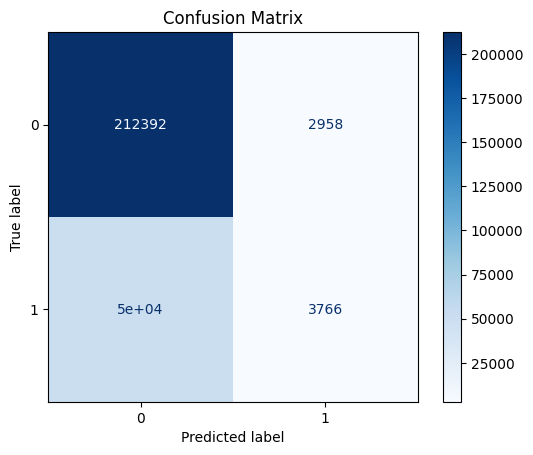

In [125]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

True Negative

* Correctly approved low-risk borrowers.

False Positive

* Good customers incorrectly predicted as risky.

False Negative (Most Expensive Error)

* Defaulting customers incorrectly approved.

True Positive

* Correctly identified risky borrowers.

### ROC Curve

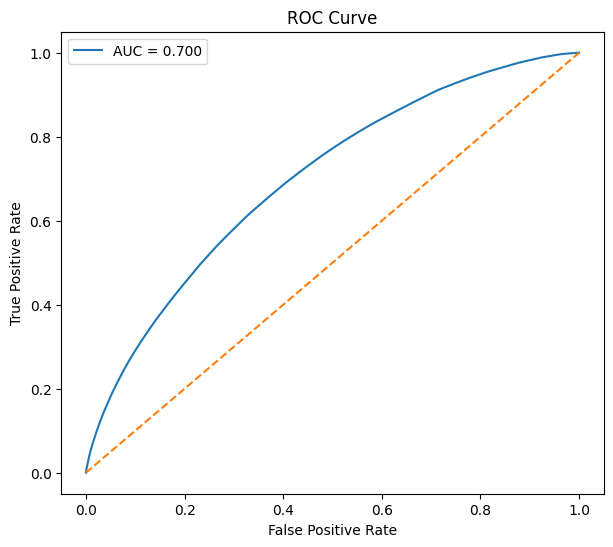

In [126]:
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Precision–Recall Curve

The ROC curve illustrates how well the model separates borrowers who default from those who repay. A curve closer to the upper-left corner indicates better discrimination. Our model achieves an AUC close to 0.70, meaning it can reasonably rank borrowers by credit risk.

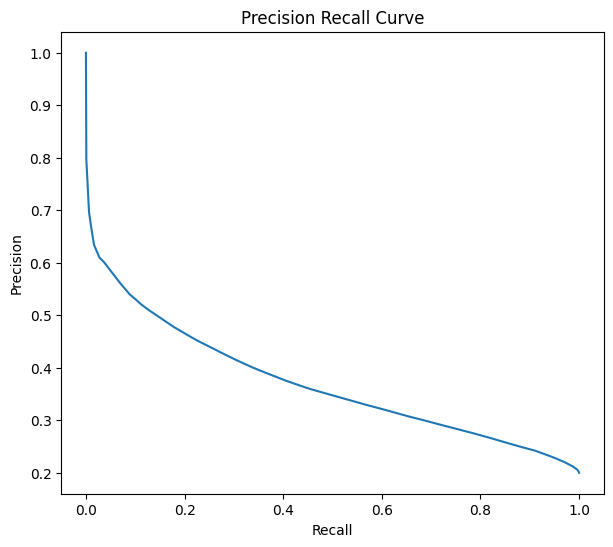

In [127]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

Since the dataset is imbalanced, the Precision–Recall curve provides a more informative evaluation than accuracy. It illustrates the trade-off between identifying more defaulters (higher recall) and reducing false alarms (higher precision).

### Probability Distribution

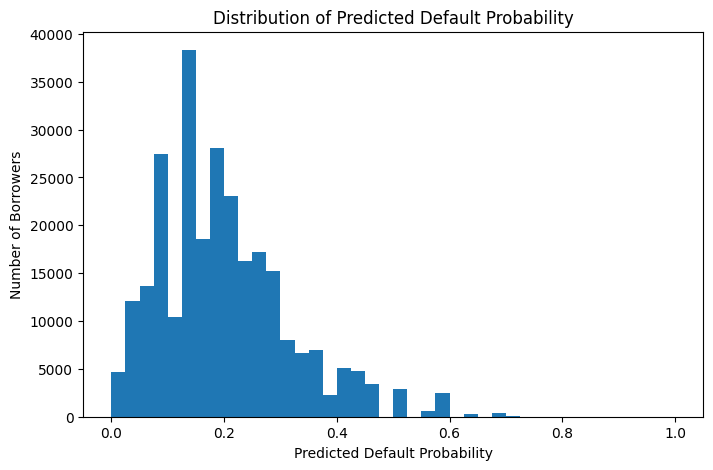

In [128]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=40
)

plt.xlabel("Predicted Default Probability")

plt.ylabel("Number of Borrowers")

plt.title("Distribution of Predicted Default Probability")

plt.show()

### Threshold Tuning

In [129]:
thresholds = [0.30,0.40,0.50,0.60]

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    results.append({

        "Threshold":t,

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1":f1_score(y_test,pred)

    })

threshold_table = pd.DataFrame(results)

threshold_table

,Threshold,Precision,Recall,F1
0,0.3,0.403133,0.330994,0.363519
1,0.4,0.476868,0.179021,0.260316
2,0.5,0.559359,0.070867,0.125797
3,0.6,0.671660,0.010015,0.019736


### Choose the Best Threshold

In [130]:
best_threshold = threshold_table.loc[
    threshold_table["F1"].idxmax(),
    "Threshold"
]

print(best_threshold)

0.3


### Feature Importance

In [131]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

In [132]:
# Recursively unwrap CalibratedClassifierCV / FrozenEstimator layers to reach XGBoost
def unwrap_estimator(est):
    if hasattr(est, 'calibrated_classifiers_'):
        return unwrap_estimator(est.calibrated_classifiers_[0].estimator)
    if hasattr(est, 'estimator'):
        return unwrap_estimator(est.estimator)
    return est

xgb_classifier = unwrap_estimator(classifier)
print(f"Unwrapped to: {type(xgb_classifier).__name__}")

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_classifier.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

Unwrapped to: XGBClassifier


,Feature,Importance
1,num__term,0.387051
63,cat__term_category_Long Term,0.082045
49,cat__fico_bucket_Very Good,0.071415
15,cat__home_ownership_MORTGAGE,0.051660
11,num__fico,0.036941
47,cat__fico_bucket_Fair,0.035645
41,cat__income_bucket_Low,0.026950
19,cat__home_ownership_RENT,0.025909
21,cat__purpose_credit_card,0.018946
48,cat__fico_bucket_Good,0.016638


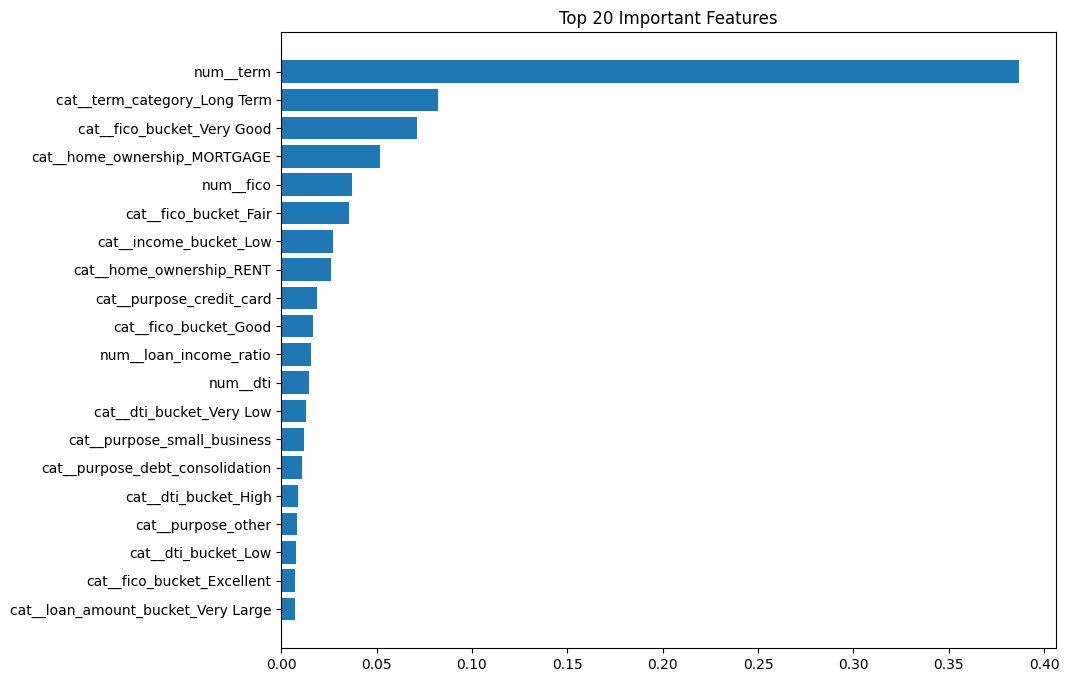

In [133]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

### SHAP Explainability

In [134]:
# Use the unwrapped XGBoost (xgb_classifier defined in the cell above)
explainer = shap.TreeExplainer(xgb_classifier)

In [135]:
sample_size = min(2000, X_test_processed.shape[0])

X_sample = X_test_processed[:sample_size]

shap_values = explainer.shap_values(X_sample)

### SHAP Summary Plot

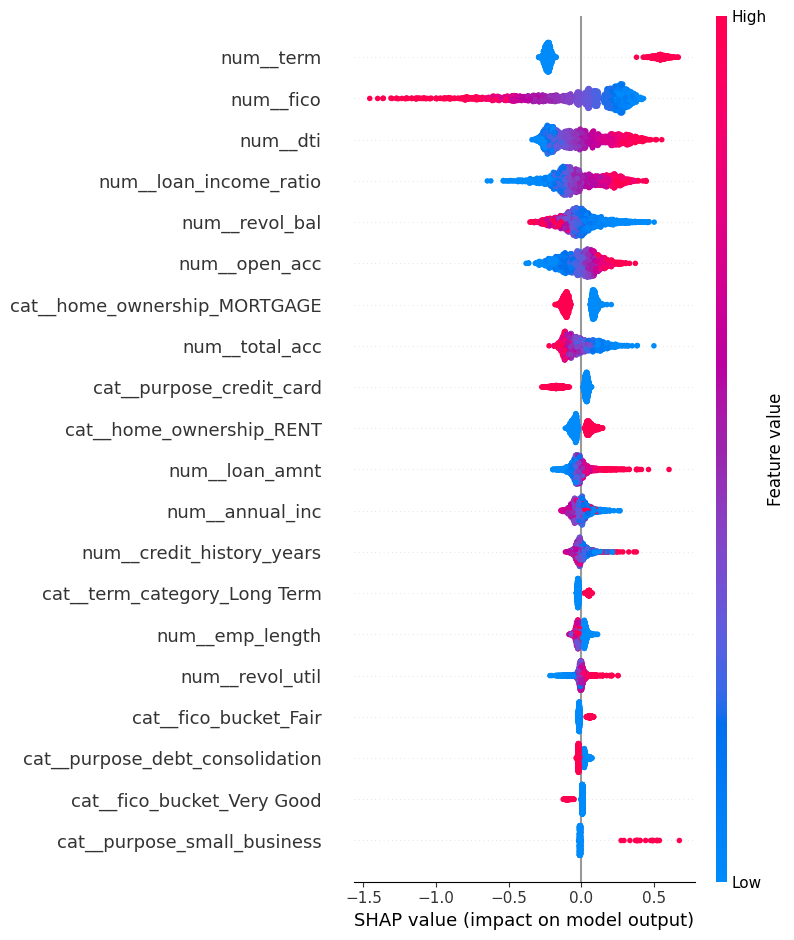

In [136]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

Explain how features such as FICO score, debt-to-income ratio, loan-to-income ratio, revolving utilization, and credit history length influence default risk.

### Explain One Borrower

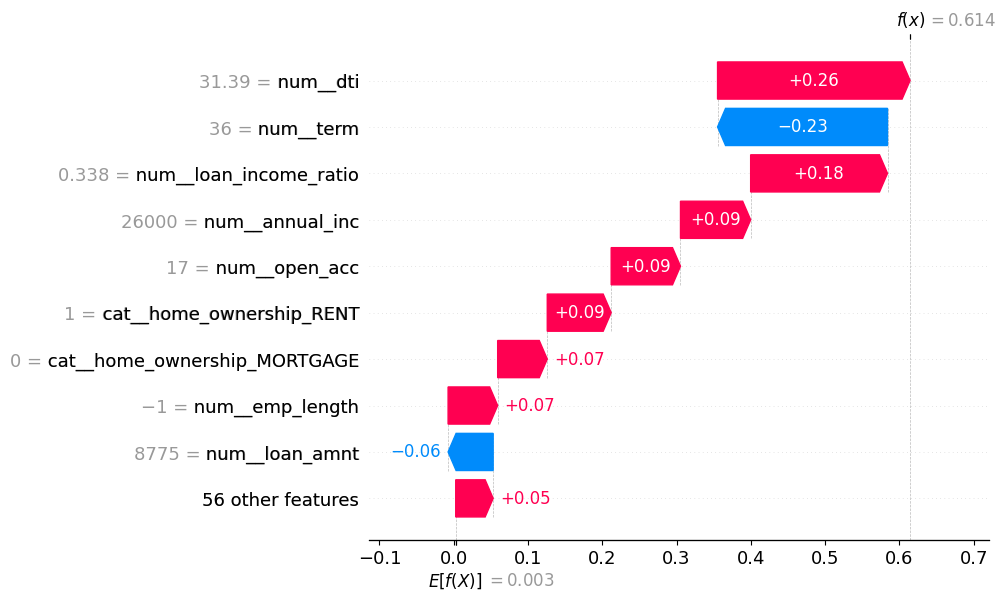

In [137]:
borrower_index = 10

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[borrower_index],
        base_values=explainer.expected_value,
        data=X_sample[borrower_index],
        feature_names=feature_names
    )
)

### Create Risk Bands

In [138]:
prediction_output = X_test.copy()

prediction_output["Actual_Default"] = y_test.values

prediction_output["Probability"] = y_prob

prediction_output["Prediction"] = (y_prob >= best_threshold).astype(int)

In [139]:
prediction_output["Risk_Band"] = pd.cut(

    prediction_output["Probability"],

    bins=[0,0.20,0.40,0.60,0.80,1],

    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]

)

## Export predicted data

In [140]:
prediction_output.to_csv(
    "../data/portfolio_predictions.csv",
    index=False
)

In [141]:
# --- STAGE 1 PRE-SCREENING MODEL (REJECT INFERENCE) ---
# We will build a proxy model using features available at application time
# to score the rejected applicants, and then train a Stage 1 Pre-Screener.

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
import joblib

# 1. Load Rejected Data
rejected_df = pd.read_csv("../data/cleaned_rejected_loans.csv")

# Common features
stage1_features = ['loan_amnt', 'fico', 'dti', 'emp_length']

# 2. Train Proxy Model on Accepted Data
# We use Logistic Regression for simplicity and explainability for Stage 1
proxy_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), stage1_features)
])

proxy_model = Pipeline([
    ("preprocessor", proxy_preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

proxy_model.fit(df_model[stage1_features], df_model["is_default"])

# 3. Score Rejected Data (Fuzzy Augmentation)
X_rejected = rejected_df[stage1_features].fillna(rejected_df[stage1_features].median())
rejected_probs = proxy_model.predict_proba(X_rejected)[:, 1]

# Assume rejected applications with high probability of default would have defaulted
# We set a threshold, e.g., 0.50
rejected_df["is_default"] = (rejected_probs >= 0.50).astype(int)

# 4. Combine Datasets for Final Stage 1 Training
# Get accepted data
accepted_subset = df_model[stage1_features].copy()
accepted_subset["is_default"] = df_model["is_default"]

# Get rejected data
rejected_subset = rejected_df[stage1_features].copy()
rejected_subset["is_default"] = rejected_df["is_default"]

combined_stage1 = pd.concat([accepted_subset, rejected_subset], ignore_index=True)

X_stage1 = combined_stage1[stage1_features]
y_stage1 = combined_stage1["is_default"]

# 5. Train Final Stage 1 Pre-Screen Model
stage1_final_model = Pipeline([
    ("preprocessor", proxy_preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        max_depth=4,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

stage1_final_model.fit(X_stage1, y_stage1)

# Save Stage 1 Model
joblib.dump(stage1_final_model, "../models/stage1_prescreen_model.pkl")
print("Stage 1 Pre-Screening Model built and saved successfully!")


Stage 1 Pre-Screening Model built and saved successfully!
